In [1]:
import drjit as dr
import numpy as xp
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import torch as th 
from drjit.cuda import Array2f, Array1f, ArrayXf, Float, TensorXf, Float16, TensorXf16

device = th.device("cuda:0" if th.cuda.is_available() else "cpu")

In [2]:
import sys
sys.path.append("src")
import xrt_toolkit as xtk

Loaded weights from gpu_3D_spline_weights_drjit.npz.


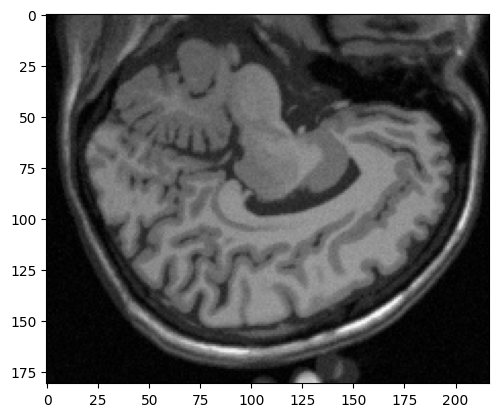

In [3]:
import nibabel as nib
img = nib.load('trash/isbi_data/phantom_mri.mnc').get_fdata()[:, :, 78:84] #181, 217, 181
plt.imshow(img[:,:,img.shape[2]//2], cmap='gray')

## Test lots of data

In [9]:
size_x = img.shape[1]  # 217
size_y = img.shape[2]  # 181

# num_angles = 65 # 75
# detector_count_x = img.shape[1]-30  # 217 -20
# detector_count_y = img.shape[2]  # 181
# x = xp.array(img)

num_angles = 75 # 75
detector_count_x = img.shape[1]-20  # 217 -20
detector_count_y = img.shape[2]  # 181
x = xp.array(img)

angles = xp.linspace(0, xp.pi, num_angles, dtype=xp.float32, endpoint=False)
detector_spec = xtk.DetectorSpec((size_x,size_y), (detector_count_x, detector_count_y))
ray_spec = xtk.parallel_beam(Float(angles), detector_spec)

knot_spec = xtk.UniformSpec(start=(-img.shape[0]//2, -(size_x//2), -(size_y//2)+0.5), step=(1,1,1), num=(img.shape[0], size_x, size_y))

order = 0
x_dr = Float(x.reshape(-1))

In [10]:
# x_dr = Float16(x_dr)
y_dr = xtk.xrt_struct_apply(ray_spec, knot_spec, order, x_dr)
print(y_dr.shape)
y_np = np.array(y_dr).reshape((num_angles, detector_count_x, detector_count_y))

(88650,)


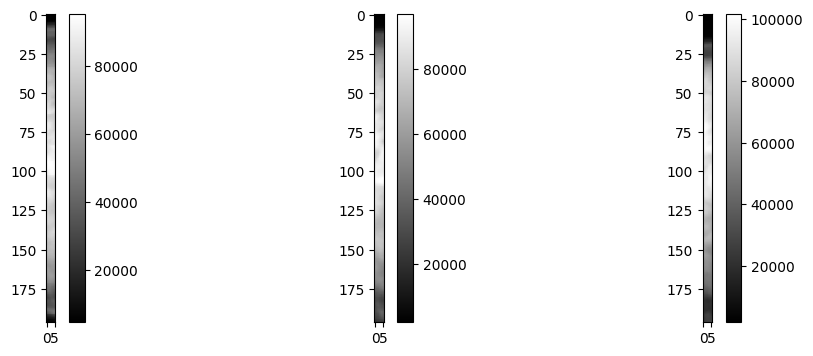

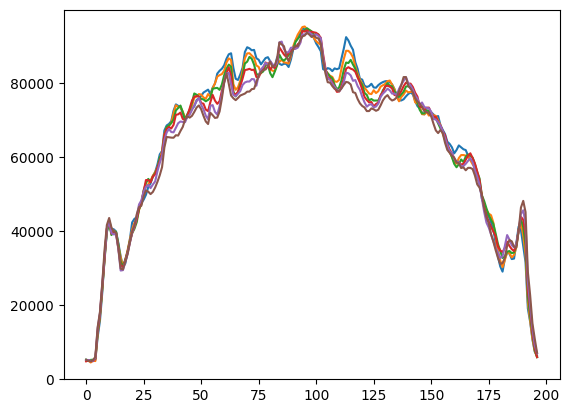

In [12]:
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(np.asarray(y_dr).reshape(len(angles), detector_count_x, detector_count_y)[0], cmap='gray')
plt.colorbar()
plt.subplot(1,3,2)
plt.imshow(np.asarray(y_dr).reshape(len(angles), detector_count_x, detector_count_y)[3], cmap='gray')
plt.colorbar()
plt.subplot(1,3,3)
plt.imshow(np.asarray(y_dr).reshape(len(angles), detector_count_x, detector_count_y)[9], cmap='gray')
plt.colorbar()
plt.show()

plt.figure()
plt.plot(np.asarray(y_dr).reshape(len(angles), detector_count_x, detector_count_y)[0])

## Reconstruction CG

In [13]:
# conjugate gradient reconstruction
fp = lambda v: xtk.xrt_struct_apply(ray_spec, knot_spec, order, v)
bp = lambda v: xtk.xrt_struct_adjoint(ray_spec, knot_spec, order, v)

# test adjoint match
x_np = np.random.randn(*x_dr.shape)
x = Float(x_np)
y_np = np.random.randn(*y_dr.shape)
y = Float(y_np)

print(*x_dr.shape, *y_dr.shape)

# print(dr.allclose(dr.dot(x, bp(y)), dr.dot(fp(x), y)))  # should be True if adjoint is correct
# print(dr.norm(dr.dot(x, bp(y)) - dr.dot(fp(x), y))) # 0.000732

235662 88650


In [14]:
def cg(A, b, x0=None, tol=1e-5, maxiter=100):
    x = x0
    print((x).shape)
    r = b - A(x)
    p = r   
    rsold = dr.dot(r, r)
    for i in range(maxiter):
        # save intermediate result
        x_rec_intermediate = np.asarray(x).reshape(img.shape)
        # np.save(f"x_rec_cg_iter_{i}_order{order}.npy", x_rec_intermediate)
        print(f"CG iteration {i}, residual {dr.sqrt(rsold)}")
        Ap = A(p)
        alpha = rsold / dr.dot(p, Ap)
        x = x + alpha * p
        r = r - alpha * Ap
        rsnew = dr.dot(r, r)
        if dr.sqrt(rsnew) < tol:
            break
        p = r + (rsnew / rsold) * p
        rsold = rsnew

    return x
# accelerated gradient descent
def acc_gd(A, b, x0=None, tol=1e-5, maxiter=100):
    x = x0
    y = x0
    t = 1
    L = 30000000.0  # Lipschitz constant (can be estimated or set)
    
    for i in range(maxiter):
        Ay = A(y)
        r = Ay - b
        grad = A(r)  # Gradient computation
        x_new = y - (1/L) * grad
        
        t_new = (1 + dr.sqrt(1 + 4 * t**2)) / 2
        y = x_new + ((t - 1) / t_new) * (x_new - x)
        
        if dr.norm(x_new - x) < tol:
            break
        
        x = x_new
        t = t_new
        
        print(f"AGD iteration {i}, residual {dr.norm(r)}")
    
    return x

A = lambda v: bp(fp(v))
b = bp(y_dr)
x0 = Float(xp.zeros_like(x_dr))
x_rec = cg(A, b, x0, tol=1e-5, maxiter=50)
x_rec_np = np.asarray(x_rec).reshape(img.shape)

(235662,)
CG iteration 0, residual [2.39478e+09]
CG iteration 1, residual [1.55516e+08]
CG iteration 2, residual [4.67973e+07]
CG iteration 3, residual [2.86588e+07]
CG iteration 4, residual [2.16857e+07]
CG iteration 5, residual [1.46979e+07]
CG iteration 6, residual [8.98037e+06]
CG iteration 7, residual [7.18647e+06]
CG iteration 8, residual [5.13512e+06]
CG iteration 9, residual [7.22938e+06]
CG iteration 10, residual [3.2994e+06]
CG iteration 11, residual [2.15258e+06]
CG iteration 12, residual [1.55951e+06]
CG iteration 13, residual [1.35449e+06]
CG iteration 14, residual [865940]
CG iteration 15, residual [588458]
CG iteration 16, residual [491683]
CG iteration 17, residual [811484]
CG iteration 18, residual [348024]
CG iteration 19, residual [264490]
CG iteration 20, residual [204179]
CG iteration 21, residual [274096]
CG iteration 22, residual [167555]
CG iteration 23, residual [169062]
CG iteration 24, residual [190552]
CG iteration 25, residual [187220]
CG iteration 26, resi

In [12]:
np.save('x_rec_splines_order1.npy', x_rec_np)

In [ ]:
x_rec_np_deg0 = np.load('x_rec_splines_v2_order0.npy') #x_rec_splines_order0.npy, img is [:, :, 78:80]
x_rec_np_deg1 = np.load('x_rec_splines_v2_order1.npy') #x_rec_splines_order1.npy
img = nib.load('phantom_mri.mnc').get_fdata()[:, :, 78:84] #181, 217, 181

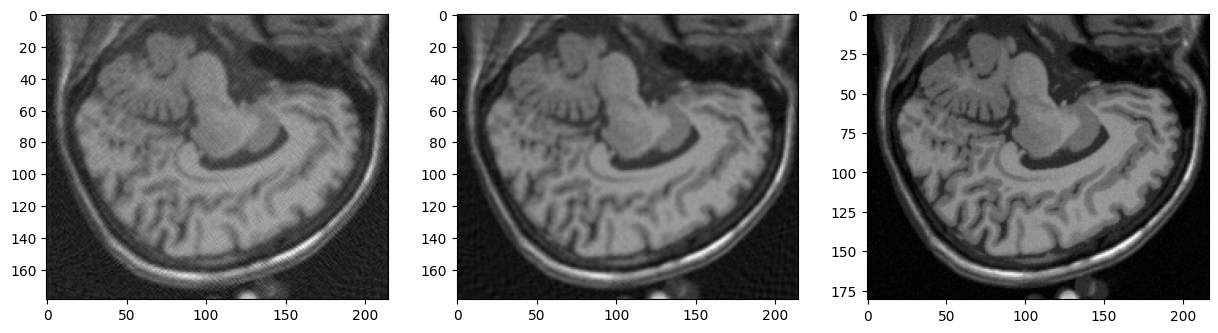

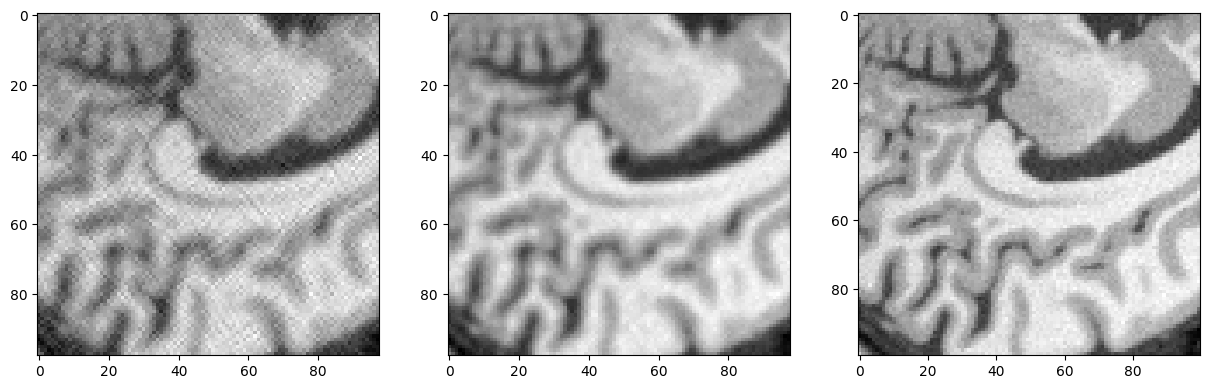

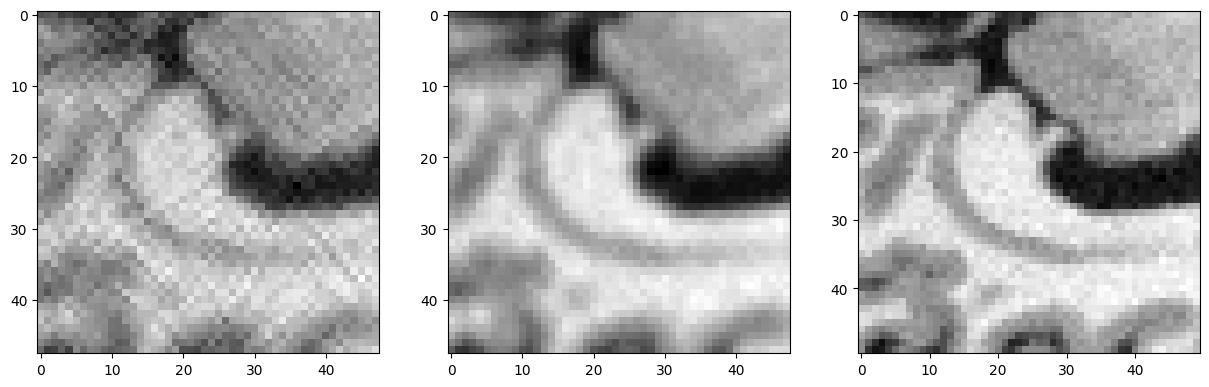

/tmp/ipykernel_4203/3348625797.py:36: UserWarning: Inputs have mismatched dtype.  Setting data_range based on image_true.
  print("PSNR order 0:", psnr(img_[:,:,img.shape[2]//2], x_rec_np_deg0_[:,:,img.shape[2]//2]))
/tmp/ipykernel_4203/3348625797.py:37: UserWarning: Inputs have mismatched dtype.  Setting data_range based on image_true.
  print("PSNR order 1:", psnr(img_[:,:,img.shape[2]//2], x_rec_np_deg1_[:,:,img.shape[2]//2]))


PSNR order 0: 21.127151749059408
PSNR order 1: 24.485366098864493
l2 error order 0: 17.230114281869035
l2 error order 1: 11.705162317333247


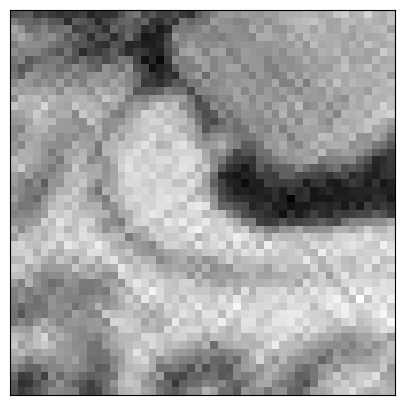

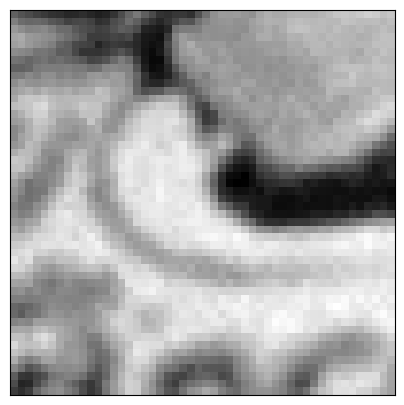

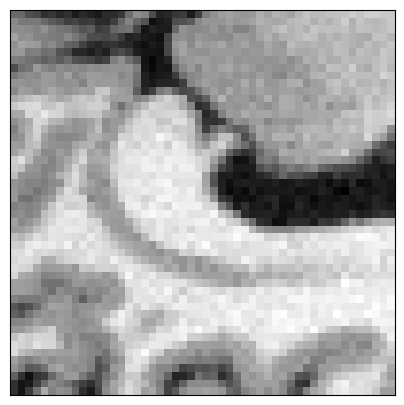

In [ ]:
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.imshow(x_rec_np_deg0[:,:,img.shape[2]//2][1:-1, 1:-1], cmap='gray')
plt.subplot(1,3,2)
plt.imshow(x_rec_np_deg1[:,:,img.shape[2]//2][1:-1, 1:-1], cmap='gray')
plt.subplot(1,3,3)
plt.imshow(img[:,:,img.shape[2]//2], cmap='gray')
plt.show()

#zoom
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.imshow(x_rec_np_deg0[50:150, 50:150, img.shape[2]//2][1:-1, 1:-1], cmap='gray')
plt.subplot(1,3,2)
plt.imshow(x_rec_np_deg1[50:150, 50:150, img.shape[2]//2][1:-1, 1:-1], cmap='gray')
plt.subplot(1,3,3)
plt.imshow(img[50:150, 50:150, img.shape[2]//2], cmap='gray')
plt.show()

# another zoom
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.imshow(x_rec_np_deg0[70:120, 70:120, img.shape[2]//2][1:-1, 1:-1], cmap='gray')
plt.subplot(1,3,2)
plt.imshow(x_rec_np_deg1[70:120, 70:120, img.shape[2]//2][1:-1, 1:-1], cmap='gray')
plt.subplot(1,3,3)
plt.imshow(img[70:120, 70:120, img.shape[2]//2], cmap='gray')
plt.show()

# compute PSNRs and SSIMs
from skimage.metrics import peak_signal_noise_ratio as psnr, structural_similarity as ssim

img_ = (img[1:-1, 1:-1] - img[1:-1, 1:-1].min()) / (img[1:-1, 1:-1].max() - img[1:-1, 1:-1].min())
x_rec_np_deg0_ = (x_rec_np_deg0[1:-1, 1:-1] - x_rec_np_deg0[1:-1, 1:-1].min()) / (x_rec_np_deg0[1:-1, 1:-1].max() - x_rec_np_deg0[1:-1, 1:-1].min())
x_rec_np_deg1_ = (x_rec_np_deg1[1:-1, 1:-1] - x_rec_np_deg1[1:-1, 1:-1].min()) / (x_rec_np_deg1[1:-1, 1:-1].max() - x_rec_np_deg1[1:-1, 1:-1].min())
print("PSNR order 0:", psnr(img_[:,:,img.shape[2]//2], x_rec_np_deg0_[:,:,img.shape[2]//2]))
print("PSNR order 1:", psnr(img_[:,:,img.shape[2]//2], x_rec_np_deg1_[:,:,img.shape[2]//2]))
print("l2 error order 0:", np.linalg.norm(img_[:,:,img.shape[2]//2] - x_rec_np_deg0_[:,:,img.shape[2]//2]))
print("l2 error order 1:", np.linalg.norm(img_[:,:,img.shape[2]//2] - x_rec_np_deg1_[:,:,img.shape[2]//2]))

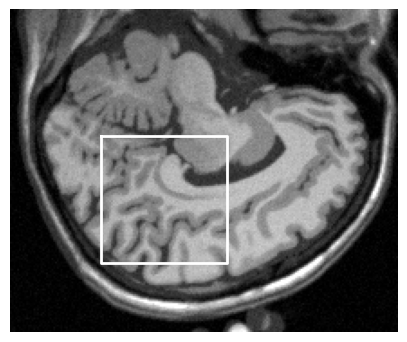

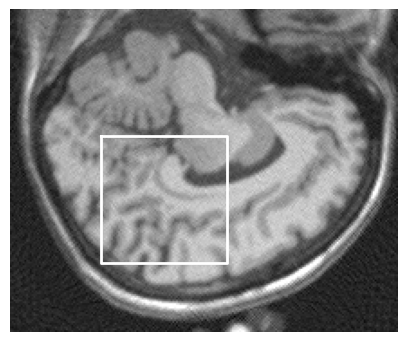

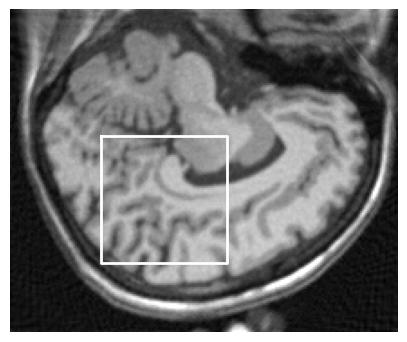

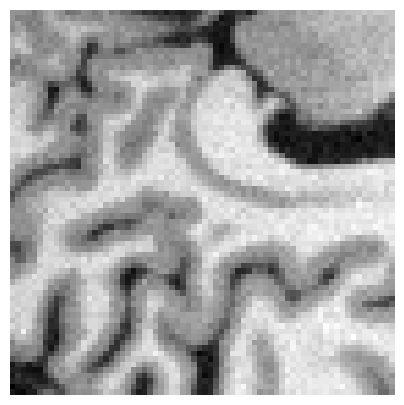

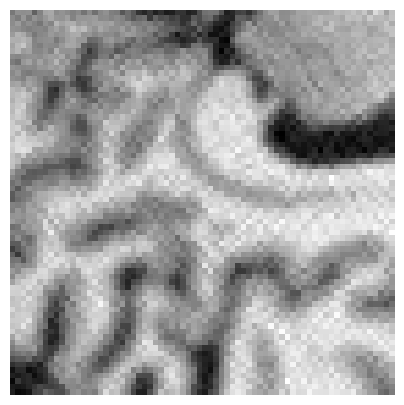

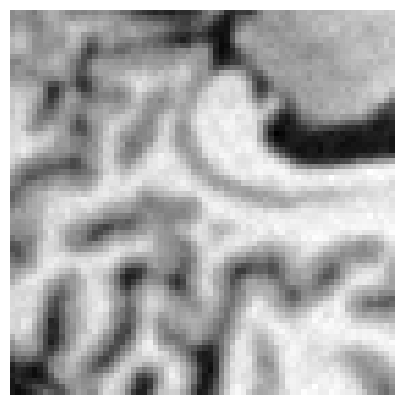

In [51]:
x_rec_np_deg0 = np.load('x_rec_splines_order0.npy') #x_rec_splines_order0.npy, img is [:, :, 78:80]
x_rec_np_deg1 = np.load('x_rec_splines_order1.npy') #x_rec_splines_order1.npy
img = nib.load('phantom_mri.mnc').get_fdata()[:, :, 78:84] #181, 217, 181
# plt.figure(figsize=(15,5))
# plt.subplot(1,3,1)
# plt.imshow(x_rec_np_deg0[:,:,img.shape[2]//2][1:-1, 1:-1], cmap='gray')
# plt.subplot(1,3,2)
# plt.imshow(x_rec_np_deg1[:,:,img.shape[2]//2][1:-1, 1:-1], cmap='gray')
# plt.subplot(1,3,3)
# plt.imshow(img[:,:,img.shape[2]//2], cmap='gray')
# plt.show()

# #zoom
# plt.figure(figsize=(15,5))
# plt.subplot(1,3,1)
# plt.imshow(x_rec_np_deg0[50:150, 50:150, img.shape[2]//2][1:-1, 1:-1], cmap='gray')
# plt.subplot(1,3,2)
# plt.imshow(x_rec_np_deg1[50:150, 50:150, img.shape[2]//2][1:-1, 1:-1], cmap='gray')
# plt.subplot(1,3,3)
# plt.imshow(img[50:150, 50:150, img.shape[2]//2], cmap='gray')
# plt.show()

# # another zoom
# plt.figure(figsize=(15,5))
# plt.subplot(1,3,1)
# plt.imshow(x_rec_np_deg0[70:120, 70:120, img.shape[2]//2][1:-1, 1:-1], cmap='gray')
# plt.subplot(1,3,2)
# plt.imshow(x_rec_np_deg1[70:120, 70:120, img.shape[2]//2][1:-1, 1:-1], cmap='gray')
# plt.subplot(1,3,3)
# plt.imshow(img[70:120, 70:120, img.shape[2]//2], cmap='gray')
# plt.show()

# compute PSNRs and SSIMs
# from skimage.metrics import peak_signal_noise_ratio as psnr, structural_similarity as ssim

img_ = (img[1:-1, 1:-1] - img[1:-1, 1:-1].min()) / (img[1:-1, 1:-1].max() - img[1:-1, 1:-1].min())
x_rec_np_deg0_ = (x_rec_np_deg0[1:-1, 1:-1] - x_rec_np_deg0[1:-1, 1:-1].min()) / (x_rec_np_deg0[1:-1, 1:-1].max() - x_rec_np_deg0[1:-1, 1:-1].min())
x_rec_np_deg1_ = (x_rec_np_deg1[1:-1, 1:-1] - x_rec_np_deg1[1:-1, 1:-1].min()) / (x_rec_np_deg1[1:-1, 1:-1].max() - x_rec_np_deg1[1:-1, 1:-1].min())
# print("PSNR order 0:", psnr(img_[:,:,img.shape[2]//2], x_rec_np_deg0_[:,:,img.shape[2]//2]))
# print("PSNR order 1:", psnr(img_[:,:,img.shape[2]//2], x_rec_np_deg1_[:,:,img.shape[2]//2]))
# print("l2 error order 0:", np.linalg.norm(img_[:,:,img.shape[2]//2] - x_rec_np_deg0_[:,:,img.shape[2]//2]))
# print("l2 error order 1:", np.linalg.norm(img_[:,:,img.shape[2]//2] - x_rec_np_deg1_[:,:,img.shape[2]//2]))

# save eps of the nine individual images plotted before, without ticks
# draw rectangle matching the z2 zoom region (rows 70:140, cols 50:120)
slice_idx = img.shape[2]//2
x0, x1 = 50, 120
y0, y1 = 70, 140

plt.figure(figsize=(5,5))
plt.imshow(img_[:,:,slice_idx], cmap='gray', vmin=0.01, vmax=0.75)
plt.plot([x0, x1, x1, x0, x0], [y0, y0, y1, y1, y0], color='white', linewidth=2)
plt.axis('off')
plt.savefig('ground_truth_image.eps', bbox_inches='tight', pad_inches=0)

plt.figure(figsize=(5,5))
plt.imshow(x_rec_np_deg0_[:,:,slice_idx], cmap='gray', vmin=0.01, vmax=0.75)
plt.plot([x0, x1, x1, x0, x0], [y0, y0, y1, y1, y0], color='white', linewidth=2)
plt.axis('off')
plt.savefig('reconstructed_image_order0.eps', bbox_inches='tight', pad_inches=0)

plt.figure(figsize=(5,5))
plt.imshow(x_rec_np_deg1_[:,:,slice_idx], cmap='gray', vmin=0.01, vmax=0.75)
plt.plot([x0, x1, x1, x0, x0], [y0, y0, y1, y1, y0], color='white', linewidth=2)
plt.axis('off')
plt.savefig('reconstructed_image_order1.eps', bbox_inches='tight', pad_inches=0)

# corrected z2: use the same region marked by the white rectangle (rows 70:140, cols 50:120)
plt.figure(figsize=(5,5))
plt.imshow(img_[y0:y1, x0:x1, slice_idx], cmap='gray')
plt.axis('off')
plt.savefig('ground_truth_image_z2.eps', bbox_inches='tight', pad_inches=0)

plt.figure(figsize=(5,5))
plt.imshow(x_rec_np_deg0_[y0:y1, x0:x1, slice_idx], cmap='gray')
plt.axis('off')
plt.savefig('reconstructed_image_order0_z2.eps', bbox_inches='tight', pad_inches=0)

plt.figure(figsize=(5,5))
plt.imshow(x_rec_np_deg1_[y0:y1, x0:x1, slice_idx], cmap='gray')
plt.axis('off')
plt.savefig('reconstructed_image_order1_z2.eps', bbox_inches='tight', pad_inches=0)


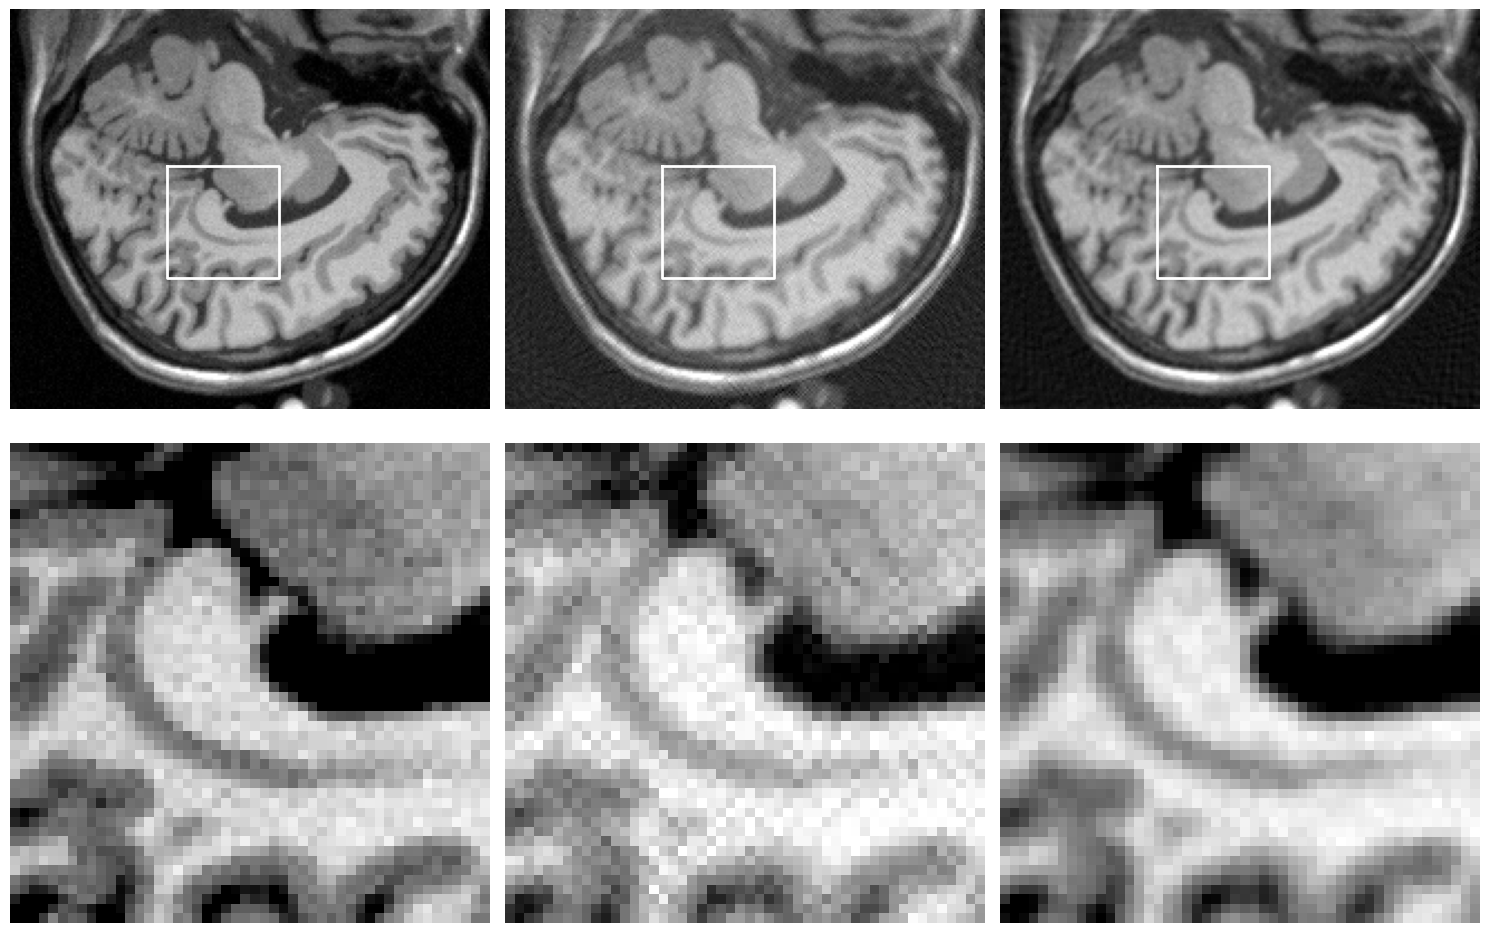

In [45]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# full images (row 0)
ax = axes[0, 0]
ax.imshow(img_[:, :, img.shape[2]//2], cmap='gray', vmin=0.01, vmax=0.75)
ax.plot([70,120,120,70,70], [70,70,120,120,70], color='white', linewidth=2)
ax.axis('off')

ax = axes[0, 1]
ax.imshow(x_rec_np_deg0_[:, :, img.shape[2]//2], cmap='gray', vmin=0.01, vmax=0.75)
ax.plot([70,120,120,70,70], [70,70,120,120,70], color='white', linewidth=2)
ax.axis('off')

ax = axes[0, 2]
ax.imshow(x_rec_np_deg1_[:, :, img.shape[2]//2], cmap='gray', vmin=0.01, vmax=0.75)
ax.plot([70,120,120,70,70], [70,70,120,120,70], color='white', linewidth=2)
ax.axis('off')

# zoomed region (row 1) using same region marked by the rectangle (70:120)
slice_idx = img.shape[2] // 2
ax = axes[1, 0]
ax.imshow(img_[70:120, 70:120, slice_idx], cmap='gray', vmin=0.25, vmax=0.6)
ax.axis('off')

ax = axes[1, 1]
ax.imshow(x_rec_np_deg0_[70:120, 70:120, slice_idx], cmap='gray', vmin=0.25, vmax=0.6)
ax.axis('off')

ax = axes[1, 2]
ax.imshow(x_rec_np_deg1_[70:120, 70:120, slice_idx], cmap='gray', vmin=0.25, vmax=0.6)
ax.axis('off')

plt.tight_layout()
plt.savefig('comparison_2x3.eps', bbox_inches='tight', pad_inches=0)


### 3D volume (5, 5, 5) and geometry

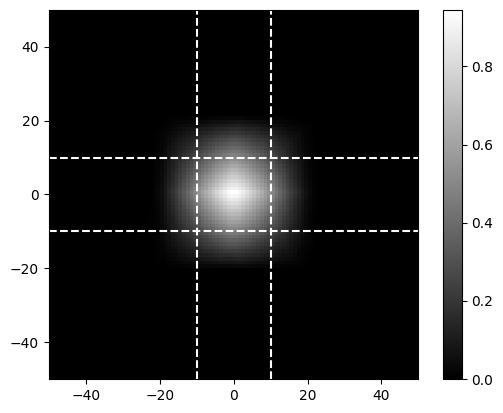

In [3]:
size = 5
num_angles = 1
detector_count = 100
x = xp.zeros((size, size, size), dtype=xp.float32)
x[2, 2, 2] = 1.0

angles = xp.linspace(-0.2, xp.pi, num_angles, dtype=xp.float32, endpoint=False)
detector_spec = xtk.DetectorSpec((5,5), (detector_count, detector_count))
ray_spec = xtk.parallel_beam(Float(angles), detector_spec)

knot_spec = xtk.UniformSpec(start=(-(size//2), -(size//2), -(size//2)), step=(1,1,1), num=(size, size, size))

order = 0
x_dr = Float(x.reshape(-1))
y_dr = xtk.xrt_struct_apply(ray_spec, knot_spec, 1, x_dr)

plt.imshow(np.asarray(y_dr).reshape(len(angles), detector_count, detector_count)[0], cmap='gray', extent=[-detector_count/2, detector_count/2, -detector_count/2, detector_count/2])
plt.plot([-detector_count/2, detector_count/2], [10, 10], color='white', linestyle='--')
plt.plot([10, 10], [-detector_count/2, detector_count/2], color='white', linestyle='--')
plt.plot([-detector_count/2, detector_count/2], [-10, -10], color='white', linestyle='--')
plt.plot([-10, -10], [-detector_count/2, detector_count/2], color='white', linestyle='--')
plt.colorbar()

[[0.980067, 0.198669, 0],
 [0.980067, 0.198669, 0],
 [0.980067, 0.198669, 0],
 .. 9994 skipped ..,
 [0.980067, 0.198669, 0],
 [0.980067, 0.198669, 0],
 [0.980067, 0.198669, 0]]


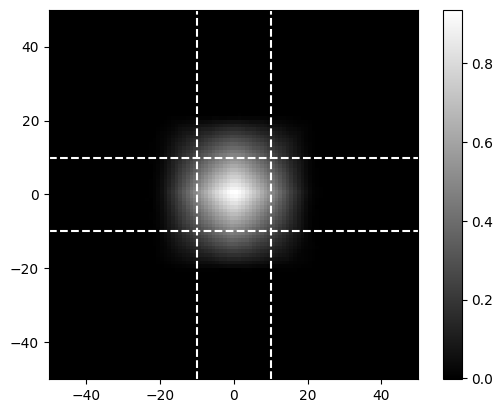

In [4]:
size = 5
num_angles = 1
detector_count = 100
x = xp.zeros((size, size, size), dtype=xp.float32)
x[2, 2, 2] = 1.0

angles = xp.linspace(+0.2, xp.pi, num_angles, dtype=xp.float32, endpoint=False)
detector_spec = xtk.DetectorSpec((5,5), (detector_count, detector_count))
ray_spec = xtk.parallel_beam(Float(angles), detector_spec)

knot_spec = xtk.UniformSpec(start=(-(size//2), -(size//2), -(size//2)), step=(1,1,1), num=(size, size, size))

order = 0
x_dr = Float(x.reshape(-1))
y_dr = xtk.xrt_struct_apply(ray_spec, knot_spec, 1, x_dr)

plt.imshow(np.asarray(y_dr).reshape(len(angles), detector_count, detector_count)[0], cmap='gray', extent=[-detector_count/2, detector_count/2, -detector_count/2, detector_count/2])
plt.plot([-detector_count/2, detector_count/2], [10, 10], color='white', linestyle='--')
plt.plot([10, 10], [-detector_count/2, detector_count/2], color='white', linestyle='--')
plt.plot([-detector_count/2, detector_count/2], [-10, -10], color='white', linestyle='--')
plt.plot([-10, -10], [-detector_count/2, detector_count/2], color='white', linestyle='--')
plt.colorbar()

[[0.198669, 0.980066, 0],
 [0.198669, 0.980066, 0],
 [0.198669, 0.980066, 0],
 .. 9994 skipped ..,
 [0.198669, 0.980066, 0],
 [0.198669, 0.980066, 0],
 [0.198669, 0.980066, 0]]


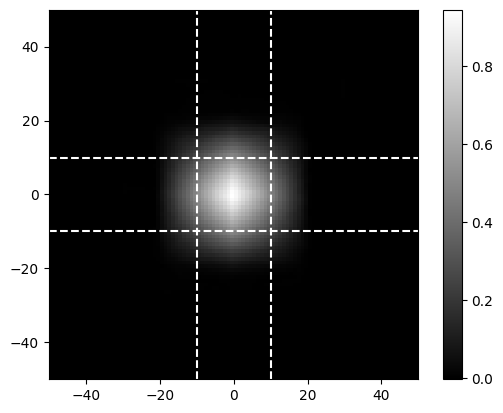

In [5]:
size = 5
num_angles = 1
detector_count = 100
x = xp.zeros((size, size, size), dtype=xp.float32)
x[2, 2, 2] = 1.0

angles = xp.linspace(np.pi/2-0.2, xp.pi, num_angles, dtype=xp.float32, endpoint=False)
detector_spec = xtk.DetectorSpec((5,5), (detector_count, detector_count))
ray_spec = xtk.parallel_beam(Float(angles), detector_spec)

knot_spec = xtk.UniformSpec(start=(-(size//2), -(size//2), -(size//2)), step=(1,1,1), num=(size, size, size))

order = 0
x_dr = Float(x.reshape(-1))
y_dr = xtk.xrt_struct_apply(ray_spec, knot_spec, 1, x_dr)

plt.imshow(np.asarray(y_dr).reshape(len(angles), detector_count, detector_count)[0], cmap='gray', extent=[-detector_count/2, detector_count/2, -detector_count/2, detector_count/2])
plt.plot([-detector_count/2, detector_count/2], [10, 10], color='white', linestyle='--')
plt.plot([10, 10], [-detector_count/2, detector_count/2], color='white', linestyle='--')
plt.plot([-detector_count/2, detector_count/2], [-10, -10], color='white', linestyle='--')
plt.plot([-10, -10], [-detector_count/2, detector_count/2], color='white', linestyle='--')
plt.colorbar()

[[-0.198669, 0.980067, 0],
 [-0.198669, 0.980067, 0],
 [-0.198669, 0.980067, 0],
 .. 9994 skipped ..,
 [-0.198669, 0.980067, 0],
 [-0.198669, 0.980067, 0],
 [-0.198669, 0.980067, 0]]


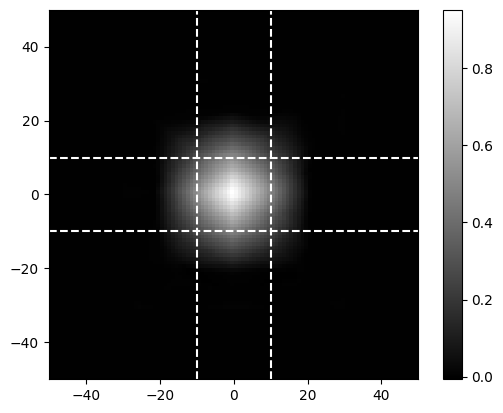

In [6]:
size = 5
num_angles = 1
detector_count = 100
x = xp.zeros((size, size, size), dtype=xp.float32)
x[2, 2, 2] = 1.0

angles = xp.linspace(np.pi/2+0.2, xp.pi, num_angles, dtype=xp.float32, endpoint=False)
detector_spec = xtk.DetectorSpec((5,5), (detector_count, detector_count))
ray_spec = xtk.parallel_beam(Float(angles), detector_spec)

knot_spec = xtk.UniformSpec(start=(-(size//2), -(size//2), -(size//2)), step=(1,1,1), num=(size, size, size))

order = 0
x_dr = Float(x.reshape(-1))
y_dr = xtk.xrt_struct_apply(ray_spec, knot_spec, 1, x_dr)

plt.imshow(np.asarray(y_dr).reshape(len(angles), detector_count, detector_count)[0], cmap='gray', extent=[-detector_count/2, detector_count/2, -detector_count/2, detector_count/2])
plt.plot([-detector_count/2, detector_count/2], [10, 10], color='white', linestyle='--')
plt.plot([10, 10], [-detector_count/2, detector_count/2], color='white', linestyle='--')
plt.plot([-detector_count/2, detector_count/2], [-10, -10], color='white', linestyle='--')
plt.plot([-10, -10], [-detector_count/2, detector_count/2], color='white', linestyle='--')
plt.colorbar()